Link Tableau : https://public.tableau.com/views/BUYACARUSEDVEHICLESDASHBOARD/BUYACARUSEDVEHICLESDASHBOARD?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

# I. Perkenalan

Halo, ini adalah portofolio tentang analisa stock, insight beserta wisdomnya tentang mobil bekas yang berada di website Craiglist.

# II. Identifikasi Masalah

Latar Belakang:
Perusahaan platform jual beli mobil bekas di Amerika bernama BuyACar, menyediakan jasa pihak ketiga yang membantu untuk menjual mobil bekas di negara Amerika dengan berbagai merk dan jenis mobil. Perusahaan tersebut ingin mengevaluasi penjualan terbaik untuk dapat bisa mengekspansi penjualan ke luar negeri. Sehingga produk yang tersedia perlu untuk cepat terjual dan diperlukan juga analisa untuk memetakan mobil yang dimiliki agar sesuai performa penjualannya. 

Topik permasalahan: Dalam mengekspansi penjualan diluar Amerika, perusahaan akan mengevaluasi list produk yang dimiliki dan menjual stock mobil agar tidak kadaluarsa dan yang baru dipergunakan sesuai market.

Problem Statement dengan metode SMART:
Meningkatkan kinerja penjualan mobil bekas untuk mencapai target penjualan 100 unit dalam waktu 6 bulan, dengan tujuan mempercepat perputaran stok dan mengurangi penumpukan kendaraan lama, dengan meningkatkan daya tarik terhadap mobil bekas/aging stock.

Specific: Meningkatkan penjualan mobil bekas atau aging stock

Measurable: Target penjualan 100 unit

Achievable: Penjualan 100 unit sangat relate karena terdapat potensi pasar yang besar terutama di wilayah California, menggunakan mobil ford dan bertransmisi automatic

Relevant: Peningkatan penjualan diperlukan untuk mempercepat perputaran stok, khususnya mobil lama/antik dan relevansi serta keunggulan fitur pada mobil baru, serta meningkatkan daya tarik konsumen melalui variasi produk.

Time-bound: 6 bulan.

Penjabaran masalah:
1. Di negara bagian mana stock mobil bekas terbanyak?
2. Apakah merk mobil mempengaruhi penjualan? Merk/manufacture apa yang paling banyak dijual?
3. Bagaimana distribusi tahun produksi kendaraan di dalam stock mobil yang dimiliki? 
4. Bagaimana performa stock mobil berdasarkan transmisinya? 
5. Bagaimana distribusi harga pada list mobil bekas? Temukan rata-rata, median, standar deviasi, skewness, dan kurtosis guna mengetahui potensi ada/tidaknya outlier?
6. Apakah ada perbedaan rata-rata harga mobil berbasis bahan bakar listrik (hybrid dan electric) dengan bahan bakar minyak (gas, diesel, dan other)?



# III. Data Loading

Sumber Referensi Data : https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data/data

In [100]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

menggunakan package pandas untuk pengolahan data, scipy untuk pengolahan hipotesis two sample independent, numpy untuk perhitungan rata2 dsb, matplotlib.pyplot dan seaborn untuk visualisasi.

In [101]:
df = pd.read_csv('vehicles2.csv')

untuk memasukan file csv vehicles2.csv ke dalam DataFrame.

# IV. Data Cleaning

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270254 entries, 0 to 270253
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            270254 non-null  int64  
 1   url           270254 non-null  object 
 2   region        270254 non-null  object 
 3   region_url    270254 non-null  object 
 4   price         270254 non-null  int64  
 5   year          269898 non-null  float64
 6   manufacturer  259710 non-null  object 
 7   model         266824 non-null  object 
 8   condition     169484 non-null  object 
 9   cylinders     166415 non-null  object 
 10  fuel          268394 non-null  object 
 11  odometer      268682 non-null  float64
 12  title_status  264741 non-null  object 
 13  transmission  268946 non-null  object 
 14  VIN           144013 non-null  object 
 15  drive         190056 non-null  object 
 16  size          90016 non-null   object 
 17  type          205392 non-null  object 
 18  pain

mengecek struktur DataFrame, dengan data awal sebanyak 270.254 row dan 24 kolom. Berbentuk float 5 kolom, integer 2 kolom dan string 18 kolom. Size file sebanyak 51.5 MB.

In [103]:
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df) * 100)
missing_summary = pd.DataFrame ({'missing_counts': missing_counts, 'missing_percentage': missing_percentage})
print(missing_summary)

              missing_counts  missing_percentage
id                         0            0.000000
url                        0            0.000000
region                     0            0.000000
region_url                 0            0.000000
price                      0            0.000000
year                     356            0.131728
manufacturer           10544            3.901515
model                   3430            1.269176
condition             100770           37.287145
cylinders             103839           38.422743
fuel                    1860            0.688241
odometer                1572            0.581675
title_status            5513            2.039933
transmission            1308            0.483989
VIN                   126241           46.711982
drive                  80198           29.675046
size                  180238           66.692075
type                   64862           24.000385
paint_color            81240           30.060610
image_url           

In [104]:
df = df.dropna(subset=['posting_date', 'long', 'manufacturer', 'model', 'type'])

Menghapus row yang memiliki nihil di kolom posting_date, long, manufacturer, model dan type. Hal tersebut dilakukan karena tidak memungkinan dapat diproses apabila tidak ada 5 data tersebut.

In [105]:
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df) * 100)
missing_summary = pd.DataFrame ({'missing_counts': missing_counts, 'missing_percentage': missing_percentage})
print(missing_summary)

              missing_counts  missing_percentage
id                         0            0.000000
url                        0            0.000000
region                     0            0.000000
region_url                 0            0.000000
price                      0            0.000000
year                       0            0.000000
manufacturer               0            0.000000
model                      0            0.000000
condition              58575           30.077485
cylinders              57241           29.392494
fuel                    1237            0.635183
odometer                1187            0.609509
title_status            4795            2.462169
transmission             976            0.501163
VIN                    71220           36.570525
drive                  35237           18.093732
size                  113225           58.139535
type                       0            0.000000
paint_color            33977           17.446739
image_url           

mengecek jumlah kolom yang memiliki null dan persentasenya di kolom tersebut.

clean cylinders

In [106]:
df['cylinders'] = df.groupby('model')['cylinders'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'other')
)

Memasukan row yang terkandung dalam kolom cylinders dengan modus berdasarkan modelnya. Karena model memiliki 1 jenis cylinders, sedangkan terdapat model yang sama tetapi cylinders yang kosong/null.

In [107]:
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df) * 100)
missing_summary = pd.DataFrame ({'missing_counts': missing_counts, 'missing_percentage': missing_percentage})
print(missing_summary)

              missing_counts  missing_percentage
id                         0            0.000000
url                        0            0.000000
region                     0            0.000000
region_url                 0            0.000000
price                      0            0.000000
year                       0            0.000000
manufacturer               0            0.000000
model                      0            0.000000
condition              58575           30.077485
cylinders                  0            0.000000
fuel                    1237            0.635183
odometer                1187            0.609509
title_status            4795            2.462169
transmission             976            0.501163
VIN                    71220           36.570525
drive                  35237           18.093732
size                  113225           58.139535
type                       0            0.000000
paint_color            33977           17.446739
image_url           

Kolom cylinders telah berhasil terisi.

In [108]:
df['transmission'].mode()[0]

'automatic'

In [109]:
df['transmission'] = df['transmission'].str.replace('other', 'automatic')
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])

Mengganti row pada kolom transmission yang kosong dengan modus yaitu automatic dan other dengean automatic. Hal tersebut dilakukan karena persentasi missing hanya 0.5% sehingga dapat diganti dengan modus, dan mengganti other karena kecenderungan apabila selain manual, transmisi pasti dicombine dengan automatic, karena tidak ada jenis lain yang sama dengan istilah manual selain manual itu sendiri.

In [110]:
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df) * 100)
missing_summary = pd.DataFrame ({'missing_counts': missing_counts, 'missing_percentage': missing_percentage})
print(missing_summary)

              missing_counts  missing_percentage
id                         0            0.000000
url                        0            0.000000
region                     0            0.000000
region_url                 0            0.000000
price                      0            0.000000
year                       0            0.000000
manufacturer               0            0.000000
model                      0            0.000000
condition              58575           30.077485
cylinders                  0            0.000000
fuel                    1237            0.635183
odometer                1187            0.609509
title_status            4795            2.462169
transmission               0            0.000000
VIN                    71220           36.570525
drive                  35237           18.093732
size                  113225           58.139535
type                       0            0.000000
paint_color            33977           17.446739
image_url           

pengecekan kembali bahwa transmission telah terisi semua.

In [111]:
df['condition'] = df['condition'].fillna('unknown')
df['paint_color'] = df['paint_color'].fillna('unknown')

Memasukan row yang kosong pada kolom condition dan paint_color dengan 'unknown' karena memiliki persentasi missing <= 30% sehingga diperlukan tetapi tidak dapat diisi modus karena tidak dapat diperkirakan mobil tersebut kondisinya dan dapat mempengaruhi analisa.

In [112]:
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df) * 100)
missing_summary = pd.DataFrame ({'missing_counts': missing_counts, 'missing_percentage': missing_percentage})
print(missing_summary)

              missing_counts  missing_percentage
id                         0            0.000000
url                        0            0.000000
region                     0            0.000000
region_url                 0            0.000000
price                      0            0.000000
year                       0            0.000000
manufacturer               0            0.000000
model                      0            0.000000
condition                  0            0.000000
cylinders                  0            0.000000
fuel                    1237            0.635183
odometer                1187            0.609509
title_status            4795            2.462169
transmission               0            0.000000
VIN                    71220           36.570525
drive                  35237           18.093732
size                  113225           58.139535
type                       0            0.000000
paint_color                0            0.000000
image_url           

file null telah berhasil diisi pada kolom condition dan paint_color.

In [113]:
df['drive'] = df.groupby('model')['drive'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'unknown'))

In [114]:
df = df.dropna(subset=['title_status', 'odometer', 'fuel'])

Memasukan null dengan modus pada kolom drive berdasarkan model, karena setiap model memiliki 1 jenis drive, apakah itu rwd, 4wd dll. Sedangkan di kolom title_status, odometer, dan fuel memiliki missing value dibawah 3% sehingga apabila dihapus row yang memiliki null di kolom tersebut tidak akan mempengaruhi analisa.

In [115]:
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df) * 100)
missing_summary = pd.DataFrame ({'missing_counts': missing_counts, 'missing_percentage': missing_percentage})
print(missing_summary)

              missing_counts  missing_percentage
id                         0            0.000000
url                        0            0.000000
region                     0            0.000000
region_url                 0            0.000000
price                      0            0.000000
year                       0            0.000000
manufacturer               0            0.000000
model                      0            0.000000
condition                  0            0.000000
cylinders                  0            0.000000
fuel                       0            0.000000
odometer                   0            0.000000
title_status               0            0.000000
transmission               0            0.000000
VIN                    70585           37.586598
drive                      0            0.000000
size                  106661           56.797112
type                       0            0.000000
paint_color                0            0.000000
image_url           

missing value telah diisi dan tersisa VIN, drive size dan county yang akan didelete karena apabila dihilangkan kolomnya tidak mempengaruhi analisa, karenat tidak dibutuhkan pada kolom VIN dan kekosongan diatas 50% sehingga sebaiknya dihapus karena tidak berarti apa-apa.

In [116]:
df = df.drop(columns=[
    'county',
    'size',
    'VIN',
])

Menghapus kolom county, size dan VIN.

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 187793 entries, 19 to 270253
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            187793 non-null  int64  
 1   url           187793 non-null  object 
 2   region        187793 non-null  object 
 3   region_url    187793 non-null  object 
 4   price         187793 non-null  int64  
 5   year          187793 non-null  float64
 6   manufacturer  187793 non-null  object 
 7   model         187793 non-null  object 
 8   condition     187793 non-null  object 
 9   cylinders     187793 non-null  object 
 10  fuel          187793 non-null  object 
 11  odometer      187793 non-null  float64
 12  title_status  187793 non-null  object 
 13  transmission  187793 non-null  object 
 14  drive         187793 non-null  object 
 15  type          187793 non-null  object 
 16  paint_color   187793 non-null  object 
 17  image_url     187793 non-null  object 
 18  state   

Mengecek kondisi stuktur data yang baru dengan seluruh null telah terisi dengan berisikan 187.793 row dan 22 kolom dan size 33 Mb.

In [118]:
df['posting_date'] = df['posting_date'].str.replace('T', ' ')
df['posting_date'] = (
    df['posting_date'].str[:-2] + ':' + df['posting_date'].str[-2:]
    ) # serta mengambil seluruh string terkecuali 2 string terakhir, menambahkan tanda titik dua (:) sebagai pemisah sebagai tandawaktu, dan mengambil 2 string terakhir.
df['posting_date'] = pd.to_datetime(df['posting_date'], utc=True).dt.tz_localize(None) #menghapus info zona waktu (UTC) dari kolom 'posting_date' dan mengonversinya menjadi tipe data datetime tanpa zona waktu.
df['posting_date'] = pd.to_datetime(df['posting_date'], format='%Y/%m/%d %H:%M') #Menjadikan format year/month/day hour:minute pada kolom 'posting_date'.

Mengganti format type posting_date dengan type datetime menggunakan pd.to_datetime, mengganti huruf T dengan spasi untuk mengikuti format datetime yang sesuai dan mudah disesuaikan.

In [119]:
print(df.dtypes)

id                       int64
url                     object
region                  object
region_url              object
price                    int64
year                   float64
manufacturer            object
model                   object
condition               object
cylinders               object
fuel                    object
odometer               float64
title_status            object
transmission            object
drive                   object
type                    object
paint_color             object
image_url               object
state                   object
lat                    float64
long                   float64
posting_date    datetime64[ns]
dtype: object


Mengecek tipe posting_date telah berhasil diganti.

In [120]:
df['id'] = df['id'].astype('object')
df['year'] = df['year'].astype('int64')

mengganti kolom id menjadi sting dan year menjadi integer.

In [121]:
df.duplicated().sum()

np.int64(0)

menghitung duplikat dengan hasil nihil duplikat.

In [122]:
df = df.reset_index(drop=True)

mereset index agar index berurutan kembali setelah manipulasi data.

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187793 entries, 0 to 187792
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            187793 non-null  object        
 1   url           187793 non-null  object        
 2   region        187793 non-null  object        
 3   region_url    187793 non-null  object        
 4   price         187793 non-null  int64         
 5   year          187793 non-null  int64         
 6   manufacturer  187793 non-null  object        
 7   model         187793 non-null  object        
 8   condition     187793 non-null  object        
 9   cylinders     187793 non-null  object        
 10  fuel          187793 non-null  object        
 11  odometer      187793 non-null  float64       
 12  title_status  187793 non-null  object        
 13  transmission  187793 non-null  object        
 14  drive         187793 non-null  object        
 15  type          187

mengecek struktur baru dengan isi 187.793 row, 22 kolom, dengan 1 tipe data datetime, 3 float, 2 integer dan 16 string. Size dile sebanyak 31.5 Mb.

In [124]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3-q1

up_bound = q3 + 1.5*iqr

print(f'Upper Boundary: {up_bound:.2f}' )

Upper Boundary: 34225.00


In [125]:
df = df[(df['price'] > 500) & (df['price'] <= 34225)]

Menghapus outlier dengan batas bawah menggunakan referensi domain knowledge dan batas atas melihat dari upperbound

In [126]:
df = df.reset_index(drop=True)

mereset kembali setelah manipulasi data penghapusan outlier

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187793 entries, 0 to 187792
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            187793 non-null  object        
 1   url           187793 non-null  object        
 2   region        187793 non-null  object        
 3   region_url    187793 non-null  object        
 4   price         187793 non-null  int64         
 5   year          187793 non-null  int64         
 6   manufacturer  187793 non-null  object        
 7   model         187793 non-null  object        
 8   condition     187793 non-null  object        
 9   cylinders     187793 non-null  object        
 10  fuel          187793 non-null  object        
 11  odometer      187793 non-null  float64       
 12  title_status  187793 non-null  object        
 13  transmission  187793 non-null  object        
 14  drive         187793 non-null  object        
 15  type          187

pengecekan struktur data kembali untuk mengecek data setelah penghapusan outlier.

In [128]:
df.to_csv('vehicles2_cleaning.csv', index=False) 

menyimpan DataFrame ke dalam file csv bernama 'vehicles2_cleaning.csv' dengan tidak memasukan index ke dalam kolom pada file csv.

# V. Analisis dan perhitungan

1. Di daerah mana daerah negara bagian terbanyak stock mobil bekas?

C:\Users\User\AppData\Local\Temp\ipykernel_32412\3768582136.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1)) # ukuran box


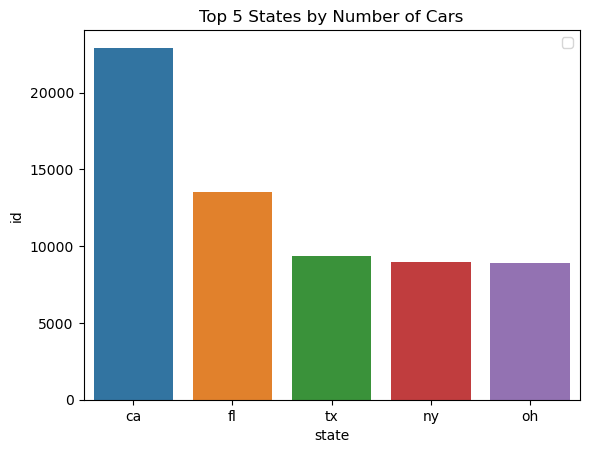

In [129]:
total_region_id = (
    df.groupby("state", as_index=False)["id"].count() 
) # Menghitung jumlah kendaraan per state dimasukan ke dalam variabel total_region_id.
top5 = total_region_id.sort_values(by="id", ascending=False).head(5)
# hitung jumlah kendaraan per state dan mengambil 5 state dengan jumlah kendaraan terbanyak, lalu menyimpan hasilnya ke dalam variabel top5.
sns.barplot(
    data=top5, x="state", y="id", orient="v", hue="state"
)
# membuat bar chart menggunakan seaborn dengan x axis = state, y axis = jumlah kendaraan (id), orientasi vertikal, dan hue/warna berdasarkan state.
plt.legend(bbox_to_anchor=(1, 1)) # ukuran box
plt.title("Top 5 States by Number of Cars") # memberikan judul pada grafik
plt.show()

Daerah dengan stock mobil bekas terbanyak berada di states california, Florida, Texas, New York dan Ohio dengan jumlah diatas 8.900 stock mobil bekas yang siap dibeli. Terbanyak yaitu di California sekitar > 22.000 unit mobil bekas.

2. Apakah merk mobil mempengaruhi stock penjualan? Merk/manufacture apa yang paling banyak dijual?

C:\Users\User\AppData\Local\Temp\ipykernel_32412\2278993319.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1)) # mengatur ukuran box


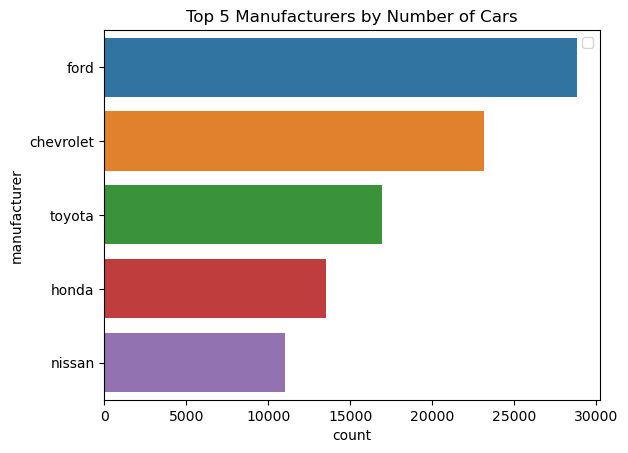

In [142]:
total_model = df.groupby('manufacturer').size().reset_index(name='count')
top5 = total_model.sort_values(by='count', ascending=False).head(5)
# Menghitung jumlah kendaraan berdasarkan manufacturer, lalu hitung jumlah kendaraanya dan ambil top 5.
sns.barplot(
    data=top5, x="count", y="manufacturer", orient="h", hue="manufacturer"
)
# membuat bar chart menggunakan seaborn dengan y axis = manufacturer, x axis = jumlah kendaraan (count), orientasi horizontal, dan hue/warna berdasarkan manufacturer.
plt.legend(bbox_to_anchor=(1, 1)) # mengatur ukuran box
plt.title("Top 5 Manufacturers by Number of Cars") # memberikan judul pada grafik
plt.show()

Merk mobil yang paling banyak dijual yaitu ford, chevrolet, toyota, honda dan nissan. Ford memiliki stok diatas 27.000 dan yang lainnya diatas 12.000 stock. Harapannya market akan diberikan variasi mobil dengan jenis berbeda dan merk yang sama karena memiliki tingkat minat orang untuk menjual yang tinggi di negara Amerika, mengingat Ford dan Chevrolet merupakan merk mobil buatan lokal/Amerika. Hal tersebut menunjukan merk lokal masih memiliki distribusi mobil bekas dengan stock tinggi di Amerika, disusul merk negara luar yaitu dari Jepang, Toyota, Honda dan Nissan.

3. Bagaimana distribusi tahun produksi kendaraan di dalam stock mobil yang dimiliki?

<Axes: xlabel='year'>

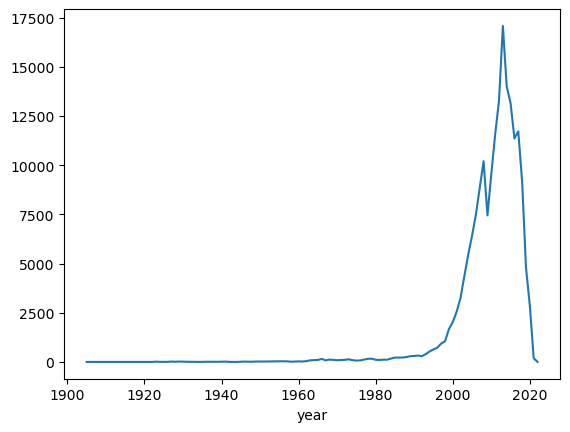

In [131]:
df.groupby('year').size().plot() # membuat line plot untuk melihat tren jumlah kendaraan berdasarkan tahun.

Pendistribusian cenderung banyak stock tahun 2000 - 2020, sebanyak 2000 unit sampai 17.500 unit. Untuk barang antik (Dibawah tahun 2000) ada tapi hanya sedikit. Barang antik harus segera dipromosikan mengingat kualitas yang semakin menurun apabila terus ada di list stock. Hal tersebut juga memperhatikan pasar yang sedikit karena target pasar kepada orang yang hanya senang mengoleksi dibanding penggunaan sehari-hari.

4. Bagaimana performa stock mobil berdasarkan transmisinya?

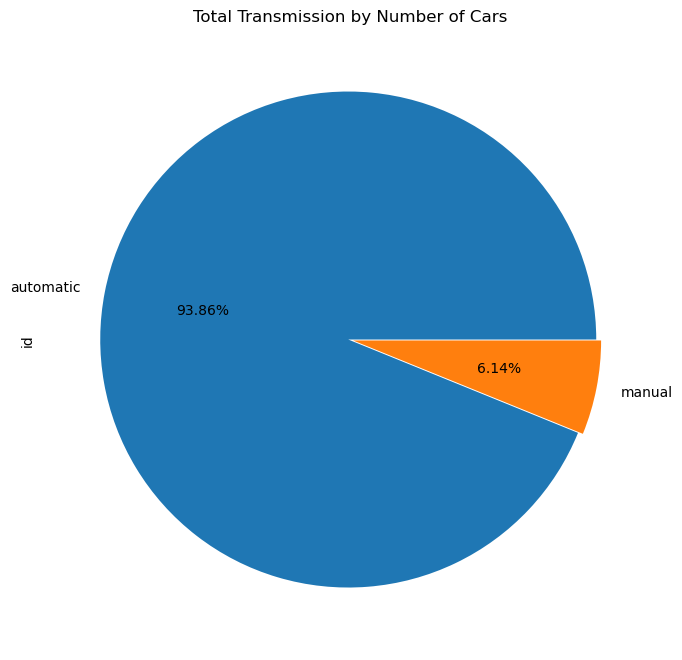

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 10)) # membuat box dan mengatur ukurannya.

total_trans_id = (
    df.groupby("transmission")["id"].count() 
)
# Menghitung jumlah kendaraan berdasarkan jenis transmisi, lalu menyimpan hasilnya ke dalam variabel total_trans_id.
total_trans_id.plot(
    kind="pie",
    autopct="%.2f%%",
    ax=ax1,  
    explode=([0.01] * len(total_trans_id)),
) # membuat pie chart dengan kind = pie, menampilkan persentase dengan format 2 desimal, menggunakan ax1 sebagai area plot, dan memberikan efek explode antara bagian pie chart.
plt.title("Total Transmission by Number of Cars") # memberikan judul pada grafik
plt.show()

Distribusi mobil matic lebih banyak dibanding manual, sebanyak 93.9%. Menekankan bahwa stock sudah terupgrade fiturnya dan bisa digunakan untuk luar dan dalam kota/region, tetapi disarankan untuk di dalam region agar kondisi awet.

5. Bagaimana distribusi harga pada list mobil bekas? Temukan rata-rata, median, standar deviasi, skewness, dan kurtosis guna mengetahui potensi ada/tidaknya outlier?

In [133]:
print('price')
print('Average:', df['price'].mean())
print('Median:', df['price'].median())
print(f"Standar Deviasi: {df['price'].std()}")
print(f"Skewness: {df['price'].skew()}")
print(f"Kurtosis: {df['price'].kurtosis()}")

'''
- Mean/Average > Median berarti Positively Skewed, distribusi data lebih banyak nilai ekstrim di sebelah kanan, tetapi hanya sedikit.
- Standar Devisasi < rata-rata, berarti data tersebar dekat dengan rata-rata, dan memiliki dispersi yang kecil.
Data stabil dan memiliki resiko yang rendah.
- Skewness > 0 menunjukan positively Skewed Distribusi, sehingga data condong ke kanan atau di atas rata-rata harga.
- Kurtosis < 0 berarti platykurtic, data tidak memiliki banyak nilai outlier
'''

price
Average: 12211.303232814855
Median: 11495.0
Standar Deviasi: 6643.817038649052
Skewness: 0.25585328729911067
Kurtosis: -1.052317710869712


'\n- Mean/Average > Median berarti Positively Skewed, distribusi data lebih banyak nilai ekstrim di sebelah kanan, tetapi hanya sedikit.\n- Standar Devisasi < rata-rata, berarti data tersebar dekat dengan rata-rata, dan memiliki dispersi yang kecil.\nData stabil dan memiliki resiko yang rendah.\n- Skewness > 0 menunjukan positively Skewed Distribusi, sehingga data condong ke kanan atau di atas rata-rata harga.\n- Kurtosis < 0 berarti platykurtic, data tidak memiliki banyak nilai outlier\n'

<Axes: xlabel='price', ylabel='Count'>

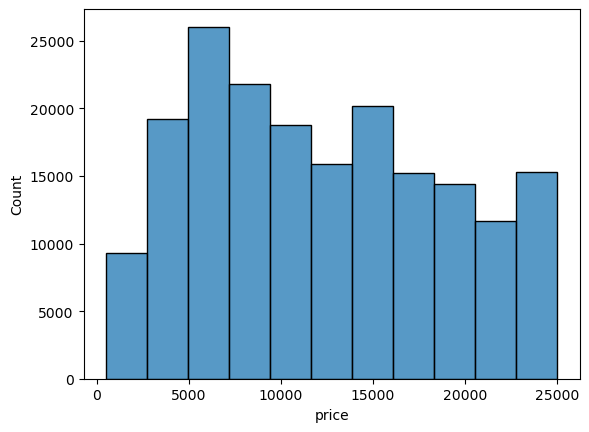

In [ ]:
sns.histplot(x=df["price"], bins=11) # membuat histogram untuk melihat distribusi harga kendaraan dengan jumlah bin sebanyak 11.

<Axes: ylabel='price'>

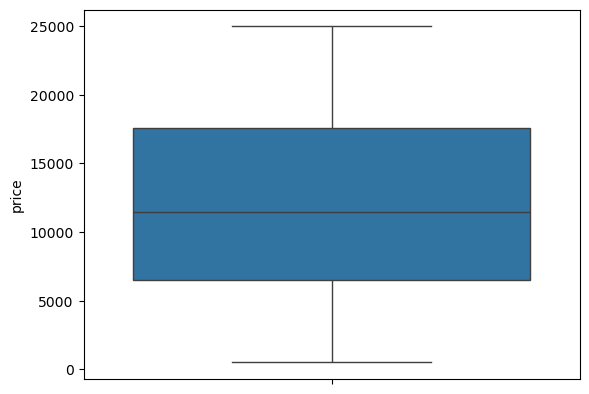

In [ ]:
sns.boxplot(y=df["price"]) # membuat boxplot.

Distribusi harga cenderung merata tetapi lebih banyak harga yang lebih dari rata-rata yaitu $12.211, tetapi harga mendekati nilai rata-rata. Berkaitan dengan outlier tidak ditemukan harga yang ekstrem ditunjukan tidak adanya lingkaran di ujung atas dan bawah chart.

6. Apakah ada perbedaan rata-rata harga mobil berbasis bahan bakar listrik (hybrid dan electric) dengan bahan bakar minyak (gas, diesel, dan other)?

H0 = Tidak terdapat perbedaan rata-rata harga antara mobil berbahan bakar listrik dan mobil berbahan bakar minyak.

H1 = Terdapat perbedaan rata-rata harga antara mobil berbahan bakar listrik dan mobil berbahan bakar minyak.


In [136]:
# pengelompokan mobil listrik
electric = df[df['fuel'].isin(['electric', 'hybrid'])]['price']

# pengelompokan mobil berbahan bakar minyak
bbm = df[df['fuel'].isin(['gas', 'diesel', 'other'])]['price']

In [137]:
t_stat, p_val = stats.ttest_ind(electric, bbm)
print('T-Statistic:',t_stat)
print('P-value:',p_val)
# P-value 0.025 kurang dari 0.05, menunjukan menolak H0.

T-Statistic: 2.227996768145386
P-value: 0.025881910146239796


In [ ]:
mean_el = electric.mean() # menghitung rata-rata harga kendaraan listrik dan dimasukan ke dalam variabel mean_el.
mean_bbm = bbm.mean() # menghitung rata-rata harga kendaraan bensin dan dimasukan ke dalam variabel mean_bbm.
print(mean_bbm) # mencetak nilai rata-rata harga kendaraan bensin.
print(mean_el) # mencetak nilai rata-rata harga kendaraan listrik.

12206.51912802693
12455.182673678384


C:\Users\User\AppData\Local\Temp\ipykernel_32412\3103253589.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1)) # ukuran box


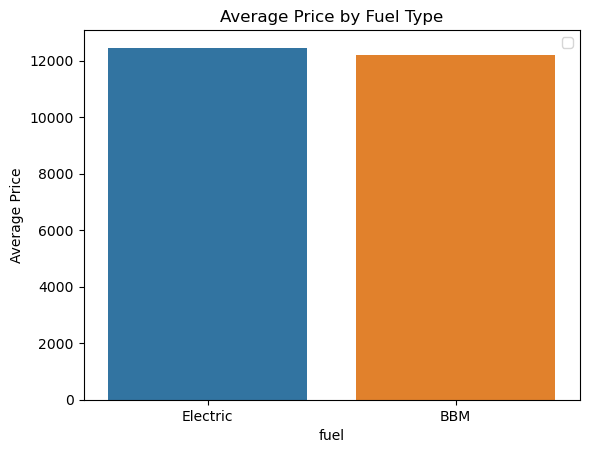

In [ ]:
avg_price_fuel = pd.DataFrame({
    'fuel': ['Electric', 'BBM'],
    'Average Price': [mean_el, mean_bbm]
}) # membuat DataFrame baru dengan kolom 'fuel' yang berisi jenis bahan bakar (Electric dan BBM) dan kolom 'Average Price' yang berisi rata-rata harga untuk masing-masing jenis bahan bakar.
sns.barplot(
    data=avg_price_fuel, x="fuel", y="Average Price", orient="v", hue="fuel"
)
# membuat bar chart menggunakan seaborn dengan x axis = state, y axis = jumlah kendaraan (id), orientasi vertikal, dan hue/warna berdasarkan state.
plt.legend(bbox_to_anchor=(1, 1)) # ukuran box
plt.title("Average Price by Fuel Type") # memberikan judul pada grafik
plt.show()

Analisa menggunakan hypothesis testing: two sample independent yang membandingkan mobil electric dengan bbm berdasarkan rata-rata harga. Hasil tes menunjukan terdapat perbedaan harga antara mobil yang berbahan bakar listrik dengan bahan bakar minyak. Tetapi perbedaan cukup sedikit yaitu $249, dimungkinkan karena dirata-ratakan dengan data yang cukup banyak, tetapi apabila dibandingkan dalam satu state akan berpotensi terlihat jauh harganya. Perbedaan harga yang tipis secara rata-rata tersebut dapat menjadi pembanding kepada calon pembeli bahwa mobil electric tidak selalu lebih mahal dengan mobil berbahan bakar BBM. Hal tersebut karena mobil electric second dipengaruhi kualitas baterai mobil dan pengecasan yang tidak mahal atau harga listrik cenderung stabil, sehingga worth it apabila memilih mobil electric.

# VI. Pengambilan Kesimpulan

Terdapat kesimpulan bahwa distribusi stok mobil bekas mayoritas berada di states California, Florida, Texas, New York dan Ohio. Oleh karena itu perlu difokuskan penjualan di wilayah tersebut. Selain itu, untuk meminimalisir logistik pengiriman unit mobil yang akan dibeli, apabila ingin dijual ke luar state, pertimbangkan jarak dan disarankan ke state tetangga. 

Merek yang mendominasi pasar adalah Ford, Chevrolet, Toyota, Honda, dan Nissan, yang menunjukkan masih tingginya stock serta minat konsumen terhadap merek lokal. Sehingga solusi dari hal tersebut dengan mempromosikan merk lokal dengan kepentingan pasar dengan menjunjung tinggi "local pride" dan disusul mobil dengan merk luar tergolong bandel yaitu buatan Jepang. 

Mayoritas kendaraan berasal dari tahun 2000–2020, sementara mobil di bawah tahun 2000 jumlahnya terbatas dan memerlukan strategi promosi khusus kepada peminat barang antik agar stock terus terupdate dan tidak kadaluarsa sehingga menjadi ronsokan. 

Mobil dengan transmisi matic mendominasi hingga 93,9%, mencerminkan preferensi pasar terhadap kenyamanan dan kemudahan penggunaan yang saat ini sudah bertansformasi bahwa mobil matic cocok disegala kondisi jarak jauh maupun dekat maupun kemudahan penggunaannya. 

Distribusi harga relatif stabil di sekitar rata-rata $12.211 tanpa adanya outlier ekstrem, sehingga diyakinkan bahwa dapat menjual mobil murah dari rata-rata dengan kondisi bagus dan terkesan antik dan promokan juga mobil mahal dengan kelengkapan fitur. 

Pelaksanaan uji hipotesis menghasilkan perbedaan rata-rata harga antara mobil listrik dan BBM memiliki perbedaan tetapi selisih tersebut relatif kecil, tetapi apabila dilihat dalam 1 state akan berpotensi terlihat jauh bedanya. Hal tersebut membuktikan mobil electric tidak selalu mahal dan ditambah biaya pengecasan yang relatif stabil karena menggunakan listrik dan ramah lingkungan/ mobil modern.

